# TP3 – Analyse en Composantes Principales (ACP)

---
## Données : Matrice du TP1 – 20 villes × 6 sports




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.linalg import eigh

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print('Bibliothèques chargées.')

Bibliothèques chargées.


## 0. Matrice de données X (TP1)

In [2]:
X = np.array([
    [1881.9,  96.8, 14.2, 25.2, 1135.5, 278.3],
    [3369.8,  96.8, 10.8, 51.6, 1331.7, 284.0],
    [4467.4, 138.2,  9.5, 34.2, 2346.1, 312.3],
    [1862.1,  83.2,  8.8, 27.6,  972.6, 203.4],
    [3499.8, 287.0, 11.5, 49.4, 2139.4, 358.0],
    [3903.2, 170.7,  6.3, 42.0, 1935.2, 292.9],
    [2620.7, 129.5,  4.2, 16.8, 1346.0, 131.8],
    [3678.4, 157.0,  6.0, 24.9, 1682.6, 194.2],
    [3840.5, 187.9, 10.2, 39.6, 1859.9, 449.1],
    [2170.2, 140.5, 11.7, 31.1, 1351.1, 256.5],
    [3920.4, 128.0,  7.2, 25.5, 1911.5,  64.1],
    [2599.6,  39.6,  5.5, 19.4, 1050.8, 172.5],
    [2828.5, 211.3,  9.9, 21.8, 1085.0, 209.0],
    [2498.7, 123.2,  7.4, 26.5, 1086.2, 153.5],
    [2685.1,  41.2,  2.3, 10.6,  812.5,  89.8],
    [2739.3, 100.7,  6.6, 22.0, 1270.4, 180.5],
    [1662.1,  81.1, 10.1, 19.1,  872.2, 123.3],
    [2469.9, 142.9, 15.5, 30.9, 1165.5, 335.5],
    [2350.7,  38.7,  2.4, 13.5, 1253.1, 170.0],
    [3177.7, 292.1,  8.0, 34.8, 1400.0, 358.9],
], dtype=float)

individus = [f'V{i+1}' for i in range(20)]
variables = ['H.Ball', 'B.Ball', 'Tennis', 'Gym', 'Natation', 'F.Ball']
m, n = X.shape

print(f'Dimensions : {m} individus (villes) x {n} variables (sports)\n')
print(pd.DataFrame(X, index=individus, columns=variables))

Dimensions : 20 individus (villes) x 6 variables (sports)

       H.Ball   B.Ball  Tennis     Gym  Natation   F.Ball
V1  1881.9000  96.8000 14.2000 25.2000 1135.5000 278.3000
V2  3369.8000  96.8000 10.8000 51.6000 1331.7000 284.0000
V3  4467.4000 138.2000  9.5000 34.2000 2346.1000 312.3000
V4  1862.1000  83.2000  8.8000 27.6000  972.6000 203.4000
V5  3499.8000 287.0000 11.5000 49.4000 2139.4000 358.0000
V6  3903.2000 170.7000  6.3000 42.0000 1935.2000 292.9000
V7  2620.7000 129.5000  4.2000 16.8000 1346.0000 131.8000
V8  3678.4000 157.0000  6.0000 24.9000 1682.6000 194.2000
V9  3840.5000 187.9000 10.2000 39.6000 1859.9000 449.1000
V10 2170.2000 140.5000 11.7000 31.1000 1351.1000 256.5000
V11 3920.4000 128.0000  7.2000 25.5000 1911.5000  64.1000
V12 2599.6000  39.6000  5.5000 19.4000 1050.8000 172.5000
V13 2828.5000 211.3000  9.9000 21.8000 1085.0000 209.0000
V14 2498.7000 123.2000  7.4000 26.5000 1086.2000 153.5000
V15 2685.1000  41.2000  2.3000 10.6000  812.5000  89.8000
V16 2739.3000

## 1. Centrage et Réduction
$$y_i^j = x_i^j - \bar{X}^j \qquad z_i^j = \frac{y_i^j}{s_j} \quad \text{où } s_j=\sqrt{\text{Var}(X^j)}$$

In [3]:
moyennes = X.mean(axis=0)
ecarts   = X.std(axis=0, ddof=0)   # division par m
Y = X - moyennes                   # matrice centrée
Z = Y / ecarts                     # matrice centrée-réduite

print('Moyennes :', dict(zip(variables, np.round(moyennes,4))))
print('Ecarts-types :', dict(zip(variables, np.round(ecarts,4))))
print('\nMatrice centrée-réduite Z :')
print(pd.DataFrame(Z, index=individus, columns=variables))

Moyennes : {'H.Ball': np.float64(2911.3), 'B.Ball': np.float64(134.32), 'Tennis': np.float64(8.405), 'Gym': np.float64(28.325), 'Natation': np.float64(1400.365), 'F.Ball': np.float64(230.88)}
Ecarts-types : {'H.Ball': np.float64(765.5634), 'B.Ball': np.float64(69.0405), 'Tennis': np.float64(3.4302), 'Gym': np.float64(10.8126), 'Natation': np.float64(423.1189), 'F.Ball': np.float64(98.6523)}

Matrice centrée-réduite Z :
     H.Ball  B.Ball  Tennis     Gym  Natation  F.Ball
V1  -1.3446 -0.5434  1.6894 -0.2890   -0.6260  0.4807
V2   0.5989 -0.5434  0.6982  2.1526   -0.1623  0.5385
V3   2.0326  0.0562  0.3192  0.5433    2.2352  0.8253
V4  -1.3705 -0.7404  0.1152 -0.0671   -1.0110 -0.2786
V5   0.7687  2.2115  0.9023  1.9491    1.7466  1.2886
V6   1.2956  0.5269 -0.6137  1.2647    1.2640  0.6287
V7  -0.3796 -0.0698 -1.2259 -1.0659   -0.1285 -1.0043
V8   1.0020  0.3285 -0.7011 -0.3168    0.6670 -0.3718
V9   1.2137  0.7761  0.5233  1.0428    1.0861  2.2120
V10 -0.9680  0.0895  0.9606  0.2566  

## 2. Matrice de corrélation R
$$R = \frac{1}{m}\;{}^t\!Z \cdot Z$$

In [4]:
R = (Z.T @ Z) / m
print('Matrice de corrélation R :')
print(pd.DataFrame(R, index=variables, columns=variables))

Matrice de corrélation R :
          H.Ball  B.Ball  Tennis    Gym  Natation  F.Ball
H.Ball    1.0000  0.4518 -0.1059 0.5173    0.8651  0.3525
B.Ball    0.4518  1.0000  0.3535 0.5904    0.5300  0.6192
Tennis   -0.1059  0.3535  1.0000 0.5344    0.1010  0.5859
Gym       0.5173  0.5904  0.5344 1.0000    0.5977  0.7501
Natation  0.8651  0.5300  0.1010 0.5977    1.0000  0.4680
F.Ball    0.3525  0.6192  0.5859 0.7501    0.4680  1.0000


## 3. Diagonalisation de R
On cherche $(\lambda_k, F_k)$ tels que $R \cdot F_k = \lambda_k \cdot F_k$

In [5]:
eigenvalues, eigenvectors = eigh(R)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

taux_inertie = eigenvalues / eigenvalues.sum() * 100
taux_cumul   = np.cumsum(taux_inertie)

df_vp = pd.DataFrame({
    'Axe'           : [f'F{k+1}' for k in range(n)],
    'Valeur propre λ': np.round(eigenvalues,4),
    'Taux inertie %' : np.round(taux_inertie,2),
    'Cumulé %'       : np.round(taux_cumul,2)
})
print(df_vp.to_string(index=False))
print('\nVecteurs propres F1, F2, F3 :')
print(pd.DataFrame(eigenvectors[:,:3], index=variables, columns=['F1','F2','F3']))

Axe  Valeur propre λ  Taux inertie %  Cumulé %
 F1           3.4859         58.1000   58.1000
 F2           1.4219         23.7000   81.8000
 F3           0.4728          7.8800   89.6800
 F4           0.2943          4.9100   94.5800
 F5           0.2187          3.6400   98.2300
 F6           0.1064          1.7700  100.0000

Vecteurs propres F1, F2, F3 :
              F1      F2      F3
H.Ball   -0.3767 -0.5533 -0.1686
B.Ball   -0.4219  0.0451  0.8757
Tennis   -0.2684  0.6489 -0.2686
Gym      -0.4741  0.1349 -0.3014
Natation -0.4298 -0.4120 -0.2044
F.Ball   -0.4457  0.2880 -0.0070


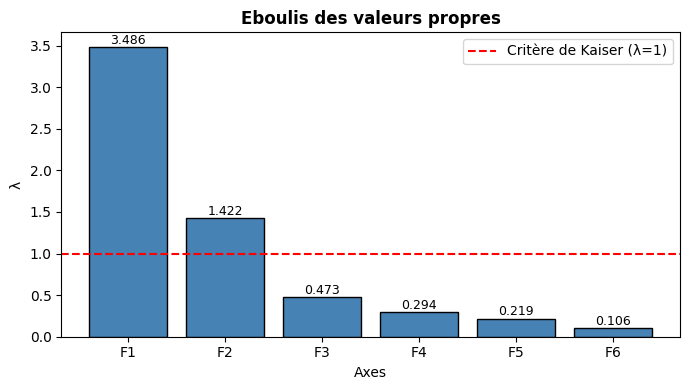

Axes retenus (λ>1) : 2
Inertie F1+F2 : 81.80%


In [6]:
# Eboulis des valeurs propres
fig, ax = plt.subplots(figsize=(7,4))
ax.bar([f'F{k+1}' for k in range(n)], eigenvalues, color='steelblue', edgecolor='black')
ax.axhline(1, color='red', linestyle='--', label='Critère de Kaiser (λ=1)')
ax.set_title('Eboulis des valeurs propres', fontweight='bold')
ax.set_xlabel('Axes')
ax.set_ylabel('λ')
ax.legend()
for i,v in enumerate(eigenvalues):
    ax.text(i, v+0.04, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Axes retenus (λ>1) : {sum(eigenvalues>1)}')
print(f'Inertie F1+F2 : {taux_cumul[1]:.2f}%')

## 4. Composantes principales (coordonnées factorielles)
$$C = Z \cdot F$$

Coordonnées factorielles (3 premiers axes) :
         F1      F2      F3
V1   0.4742  2.1729 -0.4913
V2  -1.3744  0.6095 -1.3837
V3  -2.4612 -1.5247 -1.0055
V4   1.3882  1.1268 -0.2195
V5  -3.7137  0.1744  0.6112
V6  -1.9687 -1.2603 -0.2360
V7   1.5096 -0.9687  0.6866
V8  -0.2987 -1.4191  0.2688
V9  -2.8721  0.0333 -0.2172
V10 -0.1183  1.3203 -0.0718
V11 -0.0055 -1.9810 -0.3644
V12  1.9696 -0.3276 -0.4835
V13  0.1587  0.5547  1.2133
V14  1.0983  0.1580  0.2366
V15  3.1696 -1.1128  0.1347
V16  1.0682 -0.3385 -0.0046
V17  2.2342  1.2737 -0.0128
V18 -0.7373  2.2329 -0.3153
V19  2.4045 -1.0126 -0.1305
V20 -1.9254  0.2888  1.7849


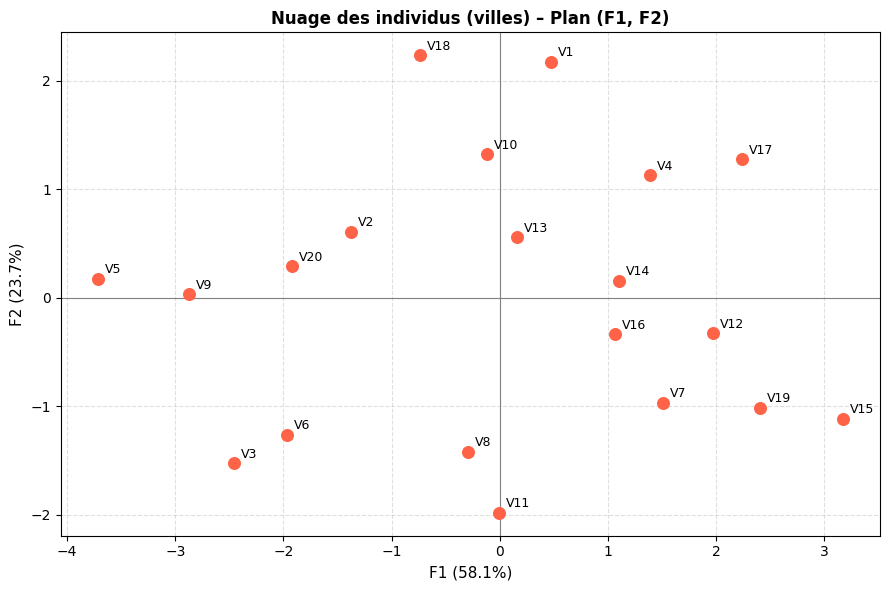

In [7]:
C = Z @ eigenvectors
print('Coordonnées factorielles (3 premiers axes) :')
print(pd.DataFrame(C[:,:3], index=individus, columns=['F1','F2','F3']))

fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(C[:,0], C[:,1], color='tomato', s=70, zorder=3)
for i,nom in enumerate(individus):
    ax.annotate(nom,(C[i,0],C[i,1]), textcoords='offset points', xytext=(5,4), fontsize=9)
ax.axhline(0,color='gray',lw=0.8); ax.axvline(0,color='gray',lw=0.8)
ax.set_xlabel(f'F1 ({taux_inertie[0]:.1f}%)',fontsize=11)
ax.set_ylabel(f'F2 ({taux_inertie[1]:.1f}%)',fontsize=11)
ax.set_title('Nuage des individus (villes) – Plan (F1, F2)', fontweight='bold')
ax.grid(True,linestyle='--',alpha=0.4); plt.tight_layout(); plt.show()

---
# PARTIE A – Nuage des INDIVIDUS

## A.1 – Carré de la distance au centre du nuage
$$d_i^2 = \|Z_i\|^2 = \sum_{j=1}^{n} z_{ij}^2 \qquad d_{i,F_k}^2 = c_{ik}^2$$

In [8]:
d2 = np.sum(Z**2, axis=1)

df_dist = pd.DataFrame({
    'Individu'       : individus,
    'd²(i,g) total'  : np.round(d2,4),
    'd² sur F1'      : np.round(C[:,0]**2,4),
    'd² sur F2'      : np.round(C[:,1]**2,4),
    'd² sur F3'      : np.round(C[:,2]**2,4),
    'd² plan F1+F2'  : np.round(C[:,0]**2+C[:,1]**2,4)
})
print(df_dist.to_string(index=False))
print(f'\nSomme des d² = {d2.sum():.4f}')
print(f'Inertie totale = n = {n}')
print('\n→ Déduction : Σd²(i,g) = Inertie totale = n = 6')
print('  (La variance totale est conservée après centrage-réduction.)')

Individu  d²(i,g) total  d² sur F1  d² sur F2  d² sur F3  d² plan F1+F2
      V1         5.6638     0.2249     4.7216     0.2414         4.9465
      V2         6.0914     1.8891     0.3715     1.9146         2.2606
      V3        10.2089     6.0573     2.3247     1.0111         8.3820
      V4         3.5439     1.9270     1.2696     0.0482         3.1966
      V5        14.8058    13.7914     0.0304     0.3736        13.8218
      V6         5.9255     3.8759     1.5884     0.0557         5.4643
      V7         3.8130     2.2788     0.9383     0.4714         3.2171
      V8         2.2870     0.0892     2.0138     0.0722         2.1030
      V9         9.5092     8.2487     0.0011     0.0472         8.2498
     V10         2.0147     0.0140     1.7432     0.0052         1.7571
     V11         6.2549     0.0000     3.9245     0.1328         3.9246
     V12         4.4793     3.8792     0.1073     0.2338         3.9865
     V13         2.4137     0.0252     0.3077     1.4720        

## A.2 – Qualité de représentation des individus
$$\cos^2(i, F_k) = \frac{c_{ik}^2}{d_i^2}$$
→ Proche de 1 : bien représenté. Proche de 0 : mal représenté.

In [9]:
cos2 = (C**2) / d2.reshape(-1,1)

df_cos2 = pd.DataFrame({
    'Individu'     : individus,
    'cos²(F1)'     : np.round(cos2[:,0],4),
    'cos²(F2)'     : np.round(cos2[:,1],4),
    'cos²(F3)'     : np.round(cos2[:,2],4),
    'Qualité F1+F2': np.round(cos2[:,0]+cos2[:,1],4)
})
print('Qualité de représentation des individus (cos²) :')
print(df_cos2.to_string(index=False))

print('\n--- Interprétation ---')
for i,nom in enumerate(individus):
    q = cos2[i,0]+cos2[i,1]
    etat = 'TRÈS BIEN' if q>=0.8 else ('bien' if q>=0.6 else ('correcte' if q>=0.4 else '⚠ MAL'))
    print(f'  {nom}: cos²(F1+F2)={q:.4f} → représentation {etat}')

Qualité de représentation des individus (cos²) :
Individu  cos²(F1)  cos²(F2)  cos²(F3)  Qualité F1+F2
      V1    0.0397    0.8336    0.0426         0.8733
      V2    0.3101    0.0610    0.3143         0.3711
      V3    0.5933    0.2277    0.0990         0.8210
      V4    0.5437    0.3583    0.0136         0.9020
      V5    0.9315    0.0021    0.0252         0.9335
      V6    0.6541    0.2681    0.0094         0.9222
      V7    0.5976    0.2461    0.1236         0.8437
      V8    0.0390    0.8805    0.0316         0.9195
      V9    0.8674    0.0001    0.0050         0.8676
     V10    0.0069    0.8652    0.0026         0.8722
     V11    0.0000    0.6274    0.0212         0.6274
     V12    0.8660    0.0240    0.0522         0.8900
     V13    0.0104    0.1275    0.6098         0.1379
     V14    0.7552    0.0156    0.0350         0.7709
     V15    0.8560    0.1055    0.0015         0.9615
     V16    0.9043    0.0908    0.0000         0.9951
     V17    0.7156    0.2326    0

## A.3 – Contribution des individus à l'inertie
$$\text{CTR}(i, F_k) = \frac{c_{ik}^2}{m \cdot \lambda_k}$$
La somme par axe = 100 %.

In [10]:
ctr = (C**2) / (m * eigenvalues)

df_ctr = pd.DataFrame({
    'Individu' : individus,
    'CTR(F1)%' : np.round(ctr[:,0]*100,4),
    'CTR(F2)%' : np.round(ctr[:,1]*100,4),
    'CTR(F3)%' : np.round(ctr[:,2]*100,4)
})
print(df_ctr.to_string(index=False))
print('\nVérification :')
for k in range(3):
    print(f'  ΣCT(F{k+1}) = {ctr[:,k].sum()*100:.2f}%')

seuil = 100/m
print(f'\nSeuil moyen = 100/{m} = {seuil:.2f}%')
for k in range(3):
    forts = [individus[i] for i in range(m) if ctr[i,k]*100 > seuil]
    print(f'  F{k+1} → individus au-dessus du seuil : {forts}')

Individu  CTR(F1)%  CTR(F2)%  CTR(F3)%
      V1    0.3226   16.6037    2.5524
      V2    2.7095    1.3065   20.2483
      V3    8.6882    8.1750   10.6926
      V4    2.7639    4.4647    0.5094
      V5   19.7815    0.1069    3.9509
      V6    5.5593    5.5856    0.5892
      V7    3.2686    3.2996    4.9858
      V8    0.1280    7.0816    0.7640
      V9   11.8315    0.0039    0.4990
     V10    0.0201    6.1299    0.0545
     V11    0.0000   13.8008    1.4044
     V12    5.5640    0.3773    2.4726
     V13    0.0361    1.0819   15.5672
     V14    1.7303    0.0878    0.5920
     V15   14.4099    4.3548    0.1919
     V16    1.6367    0.4030    0.0002
     V17    7.1600    5.7053    0.0017
     V18    0.7797   17.5329    1.0511
     V19    8.2929    3.6055    0.1800
     V20    5.3172    0.2932   33.6926

Vérification :
  ΣCT(F1) = 100.00%
  ΣCT(F2) = 100.00%
  ΣCT(F3) = 100.00%

Seuil moyen = 100/20 = 5.00%
  F1 → individus au-dessus du seuil : ['V3', 'V5', 'V6', 'V9', 'V12', 'V15'

## A.4 – Individus mal représentés (avec signe)

In [11]:
seuil_cos2 = 0.4
print(f'Individus mal représentés (cos² < {seuil_cos2}) :\n')
for k in range(3):
    print(f'  Axe F{k+1} :')
    aucun = True
    for i,nom in enumerate(individus):
        if cos2[i,k] < seuil_cos2:
            aucun = False
            signe = '+' if C[i,k]>=0 else '-'
            print(f'    {nom}: cos²={cos2[i,k]:.4f}  coord={C[i,k]:+.4f}  (côté {signe})')
    if aucun:
        print('    Aucun individu mal représenté.')

Individus mal représentés (cos² < 0.4) :

  Axe F1 :
    V1: cos²=0.0397  coord=+0.4742  (côté +)
    V2: cos²=0.3101  coord=-1.3744  (côté -)
    V8: cos²=0.0390  coord=-0.2987  (côté -)
    V10: cos²=0.0069  coord=-0.1183  (côté -)
    V11: cos²=0.0000  coord=-0.0055  (côté -)
    V13: cos²=0.0104  coord=+0.1587  (côté +)
    V18: cos²=0.0889  coord=-0.7373  (côté -)
  Axe F2 :
    V2: cos²=0.0610  coord=+0.6095  (côté +)
    V3: cos²=0.2277  coord=-1.5247  (côté -)
    V4: cos²=0.3583  coord=+1.1268  (côté +)
    V5: cos²=0.0021  coord=+0.1744  (côté +)
    V6: cos²=0.2681  coord=-1.2603  (côté -)
    V7: cos²=0.2461  coord=-0.9687  (côté -)
    V9: cos²=0.0001  coord=+0.0333  (côté +)
    V12: cos²=0.0240  coord=-0.3276  (côté -)
    V13: cos²=0.1275  coord=+0.5547  (côté +)
    V14: cos²=0.0156  coord=+0.1580  (côté +)
    V15: cos²=0.1055  coord=-1.1128  (côté -)
    V16: cos²=0.0908  coord=-0.3385  (côté -)
    V17: cos²=0.2326  coord=+1.2737  (côté +)
    V19: cos²=0.1298  coor

---
# PARTIE B – Nuage des VARIABLES (Sports)

## B.1 – Coordonnées des variables sur les axes
$$r(X^j, F_k) = \sqrt{\lambda_k} \cdot f_{jk}$$

In [12]:
coord_var = eigenvectors * np.sqrt(eigenvalues)

print('Coordonnées des variables (corrélations variable-axe) :')
print(pd.DataFrame(coord_var[:,:3], index=variables, columns=['F1','F2','F3']))

Coordonnées des variables (corrélations variable-axe) :
              F1      F2      F3
H.Ball   -0.7033 -0.6597 -0.1159
B.Ball   -0.7876  0.0538  0.6021
Tennis   -0.5010  0.7737 -0.1847
Gym      -0.8851  0.1609 -0.2072
Natation -0.8025 -0.4912 -0.1405
F.Ball   -0.8322  0.3434 -0.0048


## B.2 – Cercles de corrélation (plans F1-F2 et F1-F3)

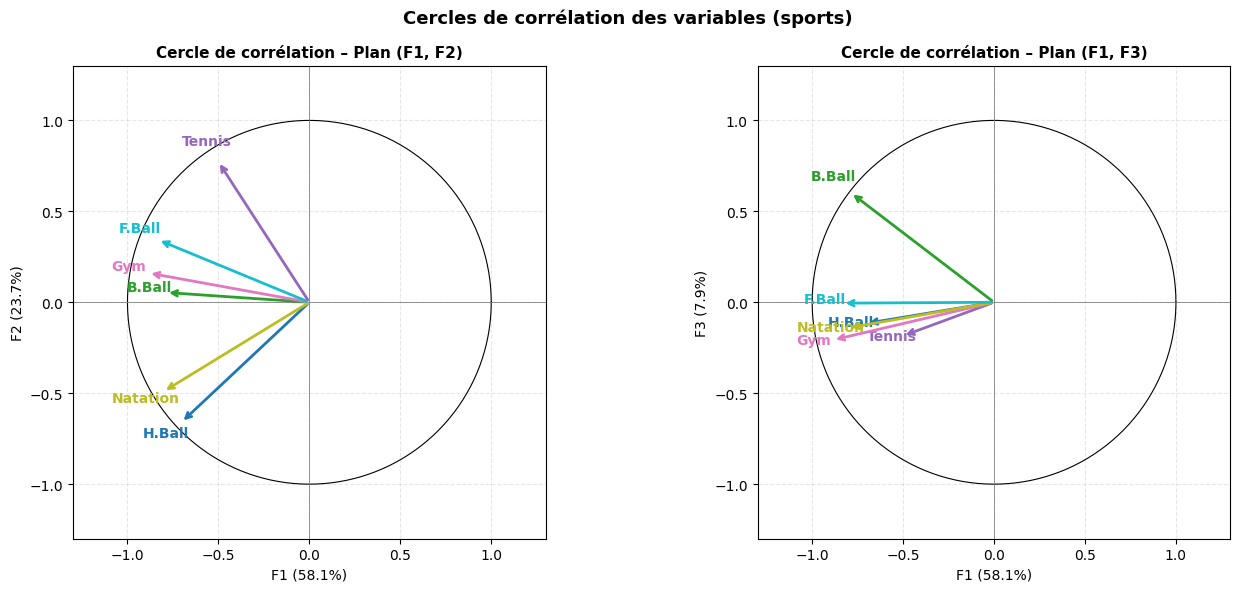

In [13]:
def cercle_corr(ax, coord, xk, yk, lx, ly, titre):
    theta = np.linspace(0,2*np.pi,300)
    ax.plot(np.cos(theta),np.sin(theta),'k-',lw=0.8)
    ax.axhline(0,color='gray',lw=0.6); ax.axvline(0,color='gray',lw=0.6)
    cols = plt.cm.tab10(np.linspace(0,1,len(variables)))
    for j,var in enumerate(variables):
        x,y = coord[j,xk], coord[j,yk]
        ax.annotate('',xy=(x,y),xytext=(0,0),
                    arrowprops=dict(arrowstyle='->',color=cols[j],lw=2))
        ax.text(x*1.12,y*1.12,var,fontsize=10,ha='center',
                color=cols[j],fontweight='bold')
    ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.3); ax.set_aspect('equal')
    ax.set_xlabel(f'{lx} ({taux_inertie[xk]:.1f}%)',fontsize=10)
    ax.set_ylabel(f'{ly} ({taux_inertie[yk]:.1f}%)',fontsize=10)
    ax.set_title(titre,fontsize=11,fontweight='bold')
    ax.grid(True,linestyle='--',alpha=0.3)

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,6))
cercle_corr(ax1,coord_var,0,1,'F1','F2','Cercle de corrélation – Plan (F1, F2)')
cercle_corr(ax2,coord_var,0,2,'F1','F3','Cercle de corrélation – Plan (F1, F3)')
plt.suptitle('Cercles de corrélation des variables (sports)',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

## B.3 – Interprétation des axes

In [14]:
print('Corrélations variables–axes :')
for j,var in enumerate(variables):
    print(f'  {var:10s}: F1={coord_var[j,0]:+.4f}  F2={coord_var[j,1]:+.4f}  F3={coord_var[j,2]:+.4f}')

seuil_r = 0.5
for k in range(3):
    print(f'\nAxe F{k+1} caractérisé par (|r|>{seuil_r}) :')
    for j,var in enumerate(variables):
        if abs(coord_var[j,k]) > seuil_r:
            sens = 'positivement' if coord_var[j,k]>0 else 'négativement'
            print(f'  {var} ({sens}) : r={coord_var[j,k]:+.4f}')

Corrélations variables–axes :
  H.Ball    : F1=-0.7033  F2=-0.6597  F3=-0.1159
  B.Ball    : F1=-0.7876  F2=+0.0538  F3=+0.6021
  Tennis    : F1=-0.5010  F2=+0.7737  F3=-0.1847
  Gym       : F1=-0.8851  F2=+0.1609  F3=-0.2072
  Natation  : F1=-0.8025  F2=-0.4912  F3=-0.1405
  F.Ball    : F1=-0.8322  F2=+0.3434  F3=-0.0048

Axe F1 caractérisé par (|r|>0.5) :
  H.Ball (négativement) : r=-0.7033
  B.Ball (négativement) : r=-0.7876
  Tennis (négativement) : r=-0.5010
  Gym (négativement) : r=-0.8851
  Natation (négativement) : r=-0.8025
  F.Ball (négativement) : r=-0.8322

Axe F2 caractérisé par (|r|>0.5) :
  H.Ball (négativement) : r=-0.6597
  Tennis (positivement) : r=+0.7737

Axe F3 caractérisé par (|r|>0.5) :
  B.Ball (positivement) : r=+0.6021


## B.4 – Qualité de représentation des variables
$$\cos^2(X^j, F_k) = \lambda_k \cdot f_{jk}^2 = r(X^j, F_k)^2$$

In [15]:
cos2_var = coord_var**2

df_cos2_var = pd.DataFrame({
    'Variable'     : variables,
    'cos²(F1)'     : np.round(cos2_var[:,0],4),
    'cos²(F2)'     : np.round(cos2_var[:,1],4),
    'cos²(F3)'     : np.round(cos2_var[:,2],4),
    'Qualité F1+F2': np.round(cos2_var[:,0]+cos2_var[:,1],4)
})
print('Qualité de représentation des variables :')
print(df_cos2_var.to_string(index=False))

print('\n--- Interprétation ---')
for j,var in enumerate(variables):
    q = cos2_var[j,0]+cos2_var[j,1]
    etat = 'TRÈS BIEN' if q>=0.8 else ('bien' if q>=0.6 else ('correcte' if q>=0.4 else '⚠ MAL'))
    print(f'  {var:10s}: cos²(F1+F2)={q:.4f} → représentation {etat}')

Qualité de représentation des variables :
Variable  cos²(F1)  cos²(F2)  cos²(F3)  Qualité F1+F2
  H.Ball    0.4946    0.4352    0.0134         0.9298
  B.Ball    0.6204    0.0029    0.3625         0.6232
  Tennis    0.2510    0.5987    0.0341         0.8497
     Gym    0.7834    0.0259    0.0429         0.8093
Natation    0.6440    0.2413    0.0197         0.8853
  F.Ball    0.6925    0.1179    0.0000         0.8104

--- Interprétation ---
  H.Ball    : cos²(F1+F2)=0.9298 → représentation TRÈS BIEN
  B.Ball    : cos²(F1+F2)=0.6232 → représentation bien
  Tennis    : cos²(F1+F2)=0.8497 → représentation TRÈS BIEN
  Gym       : cos²(F1+F2)=0.8093 → représentation TRÈS BIEN
  Natation  : cos²(F1+F2)=0.8853 → représentation TRÈS BIEN
  F.Ball    : cos²(F1+F2)=0.8104 → représentation TRÈS BIEN


## B.5 – Contribution des variables à l'inertie
$$\text{CTR}(X^j, F_k) = f_{jk}^2 / n$$

In [16]:
ctr_var = (eigenvectors**2) / n

df_ctr_var = pd.DataFrame({
    'Variable'  : variables,
    'CTR(F1)%'  : np.round(ctr_var[:,0]*100,4),
    'CTR(F2)%'  : np.round(ctr_var[:,1]*100,4),
    'CTR(F3)%'  : np.round(ctr_var[:,2]*100,4)
})
print('Contributions des variables à l\'inertie (%) :')
print(df_ctr_var.to_string(index=False))
print('\nVérification :')
for k in range(3):
    print(f'  ΣCT(F{k+1}) = {ctr_var[:,k].sum()*100:.2f}%')

Contributions des variables à l'inertie (%) :
Variable  CTR(F1)%  CTR(F2)%  CTR(F3)%
  H.Ball    2.3647    5.1015    0.4738
  B.Ball    2.9660    0.0339   12.7798
  Tennis    1.2003    7.0174    1.2025
     Gym    3.7458    0.3034    1.5137
Natation    3.0790    2.8284    0.6961
  F.Ball    3.3109    1.3820    0.0008

Vérification :
  ΣCT(F1) = 16.67%
  ΣCT(F2) = 16.67%
  ΣCT(F3) = 16.67%


## B.6 – Représentation simultanée dans deux sous-fenêtres

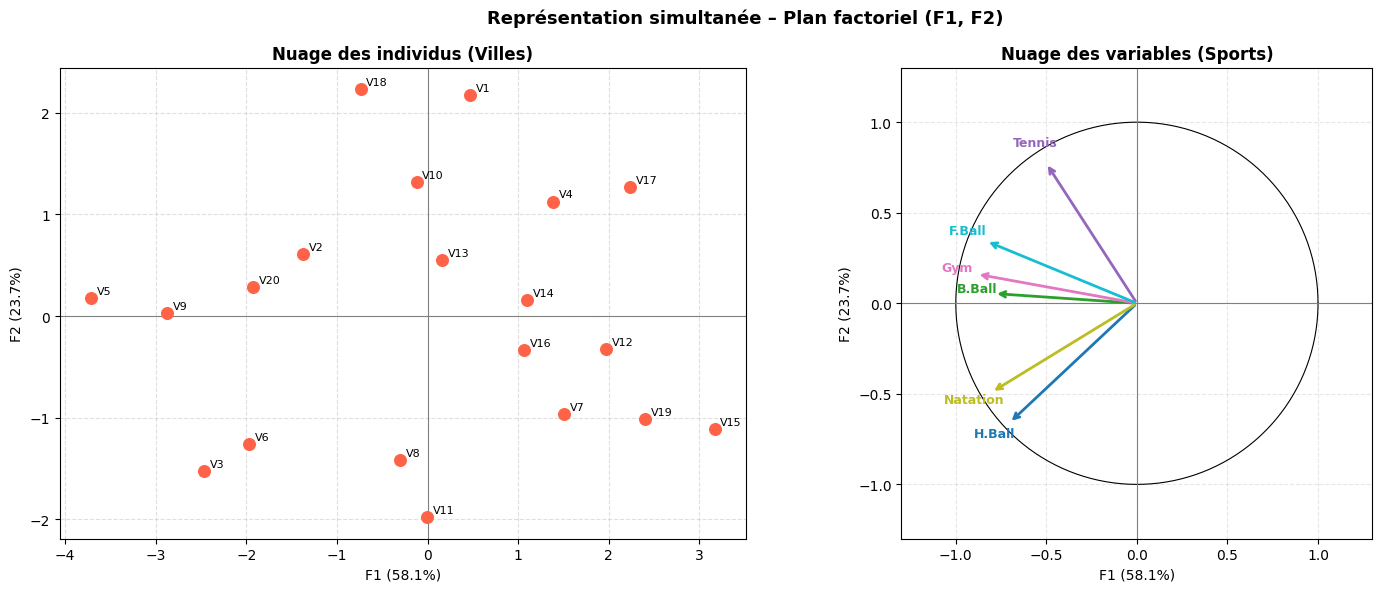

In [17]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(15,6))

# Nuage des individus
ax1.scatter(C[:,0],C[:,1],color='tomato',s=70,zorder=3)
for i,nom in enumerate(individus):
    ax1.annotate(nom,(C[i,0],C[i,1]),textcoords='offset points',xytext=(4,3),fontsize=8)
ax1.axhline(0,color='gray',lw=0.8); ax1.axvline(0,color='gray',lw=0.8)
ax1.set_xlabel(f'F1 ({taux_inertie[0]:.1f}%)'); ax1.set_ylabel(f'F2 ({taux_inertie[1]:.1f}%)')
ax1.set_title('Nuage des individus (Villes)',fontweight='bold')
ax1.grid(True,linestyle='--',alpha=0.4)

# Cercle de corrélation
theta = np.linspace(0,2*np.pi,300)
ax2.plot(np.cos(theta),np.sin(theta),'k-',lw=0.8)
ax2.axhline(0,color='gray',lw=0.8); ax2.axvline(0,color='gray',lw=0.8)
cols = plt.cm.tab10(np.linspace(0,1,len(variables)))
for j,var in enumerate(variables):
    x,y = coord_var[j,0],coord_var[j,1]
    ax2.annotate('',xy=(x,y),xytext=(0,0),
                arrowprops=dict(arrowstyle='->',color=cols[j],lw=2))
    ax2.text(x*1.12,y*1.12,var,fontsize=9,color=cols[j],fontweight='bold',ha='center')
ax2.set_xlim(-1.3,1.3); ax2.set_ylim(-1.3,1.3); ax2.set_aspect('equal')
ax2.set_xlabel(f'F1 ({taux_inertie[0]:.1f}%)'); ax2.set_ylabel(f'F2 ({taux_inertie[1]:.1f}%)')
ax2.set_title('Nuage des variables (Sports)',fontweight='bold')
ax2.grid(True,linestyle='--',alpha=0.3)

plt.suptitle('Représentation simultanée – Plan factoriel (F1, F2)',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

## B.7 – Biplot (CA Factor Map)
Individus en **rouge**, variables en **bleu**.

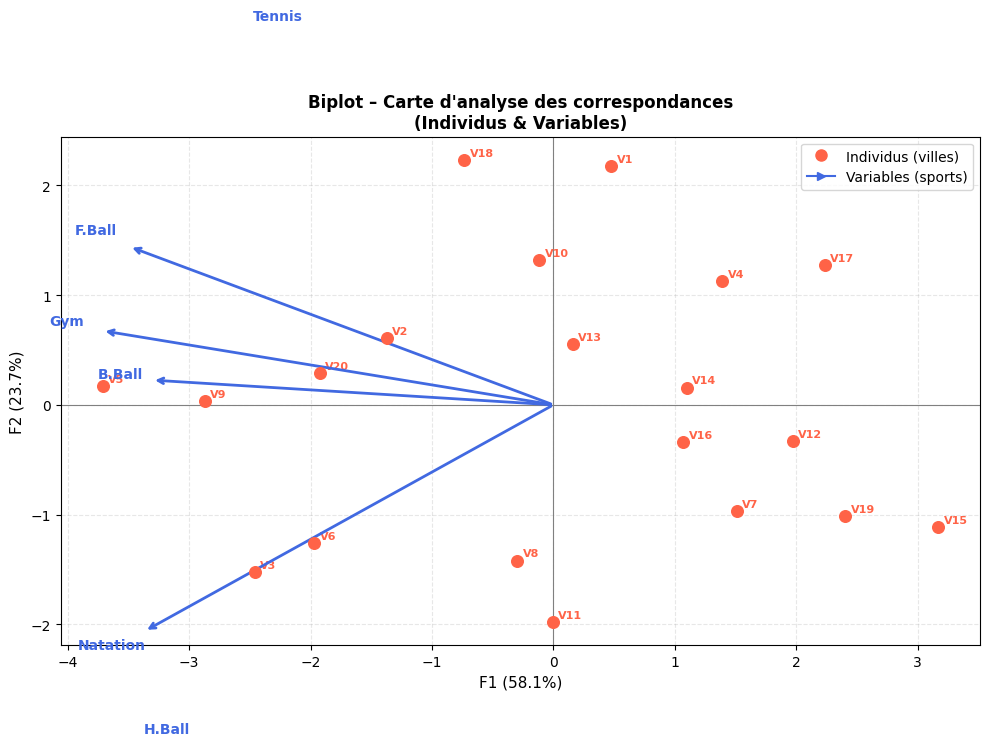

In [18]:
scale = np.max(np.abs(C[:,:2])) / np.max(np.abs(coord_var[:,:2]))

fig,ax = plt.subplots(figsize=(10,8))

ax.scatter(C[:,0],C[:,1],color='tomato',s=70,zorder=4,label='Individus (villes)')
for i,nom in enumerate(individus):
    ax.annotate(nom,(C[i,0],C[i,1]),textcoords='offset points',xytext=(4,3),
                fontsize=8,color='tomato',fontweight='bold')

for j,var in enumerate(variables):
    x = coord_var[j,0]*scale
    y = coord_var[j,1]*scale
    ax.annotate('',xy=(x,y),xytext=(0,0),
                arrowprops=dict(arrowstyle='->',color='royalblue',lw=2))
    ax.text(x*1.08,y*1.08,var,fontsize=10,color='royalblue',fontweight='bold',ha='center')

import matplotlib.lines as mlines
h1 = mlines.Line2D([],[],color='tomato',marker='o',linestyle='None',markersize=8,label='Individus (villes)')
h2 = mlines.Line2D([],[],color='royalblue',marker='>',linestyle='-',label='Variables (sports)')
ax.legend(handles=[h1,h2],fontsize=10)

ax.axhline(0,color='gray',lw=0.8); ax.axvline(0,color='gray',lw=0.8)
ax.set_xlabel(f'F1 ({taux_inertie[0]:.1f}%)',fontsize=11)
ax.set_ylabel(f'F2 ({taux_inertie[1]:.1f}%)',fontsize=11)
ax.set_title("Biplot – Carte d'analyse des correspondances\n(Individus & Variables)",
             fontsize=12,fontweight='bold')
ax.grid(True,linestyle='--',alpha=0.3)
plt.tight_layout(); plt.show()